# SEA BORN

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
%autoreload 2
%reload_ext autoreload

UsageError: Line magic function `%autoreload` not found.


In [2]:
cs=pd.read_csv('ComputerSales.csv')
crash=sns.load_dataset('car_crashes')


## Distribution Plot

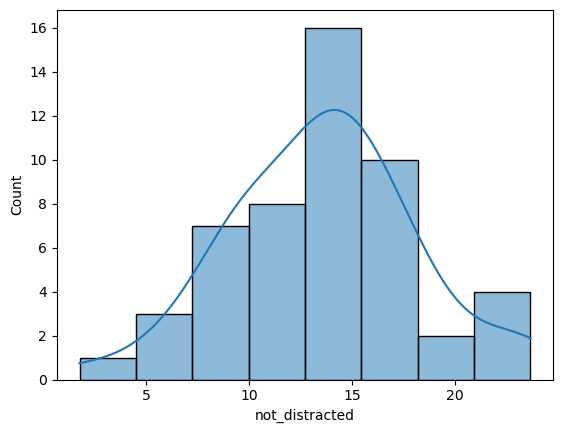

In [3]:
sns.histplot(crash['not_distracted'],kde=True,bins='auto')
plt.show()

## Joint Plot

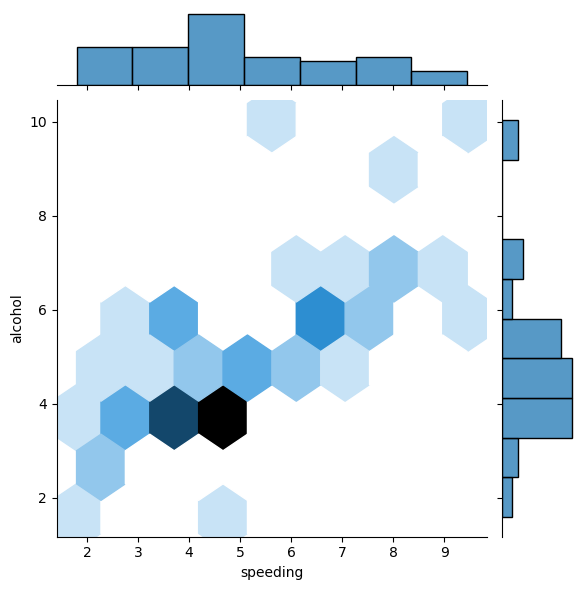

In [4]:
sns.jointplot(x='speeding',y='alcohol',data=crash,kind='hex')
plt.show()

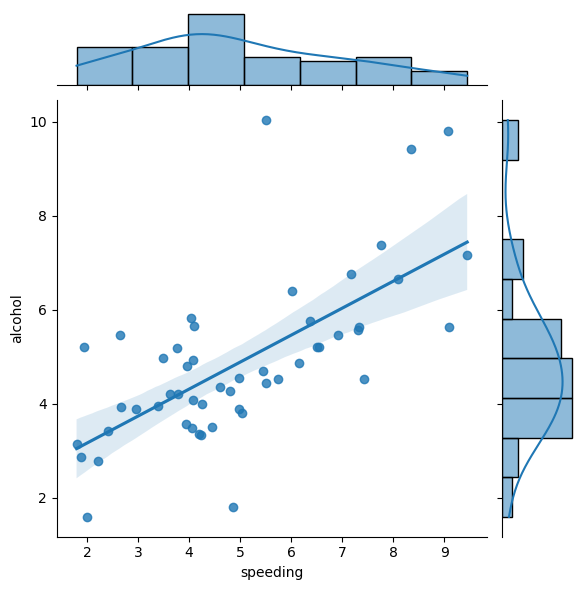

In [5]:
sns.jointplot(x='speeding',y='alcohol',data=crash,kind='reg')
plt.show()

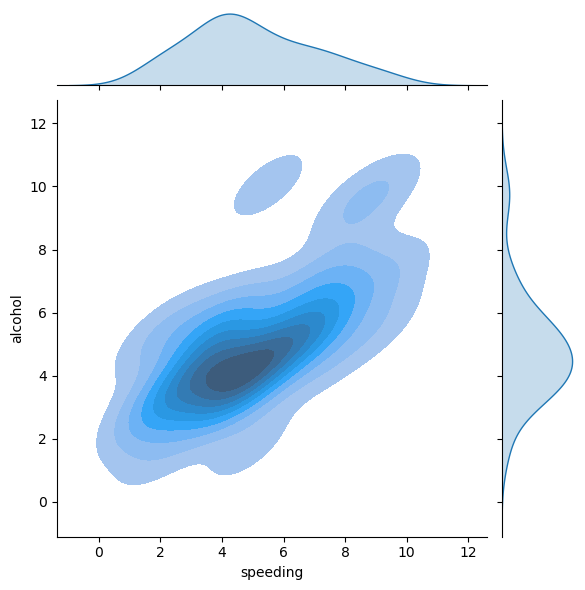

In [6]:
sns.jointplot(x='speeding',y='alcohol',data=crash,kind='kde',fill=True)
plt.show()

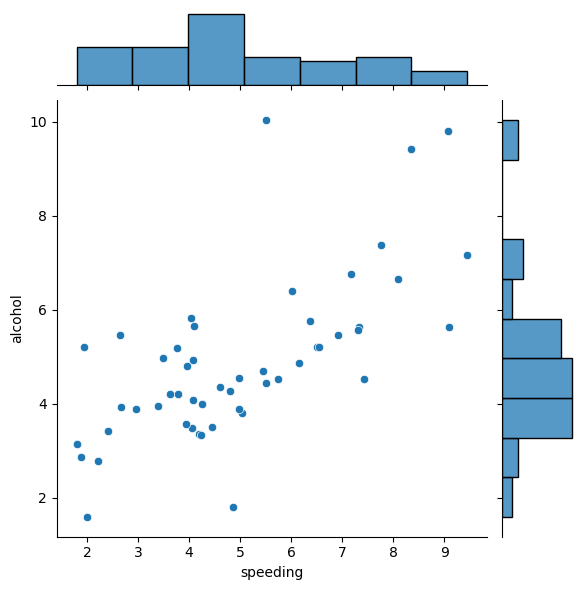

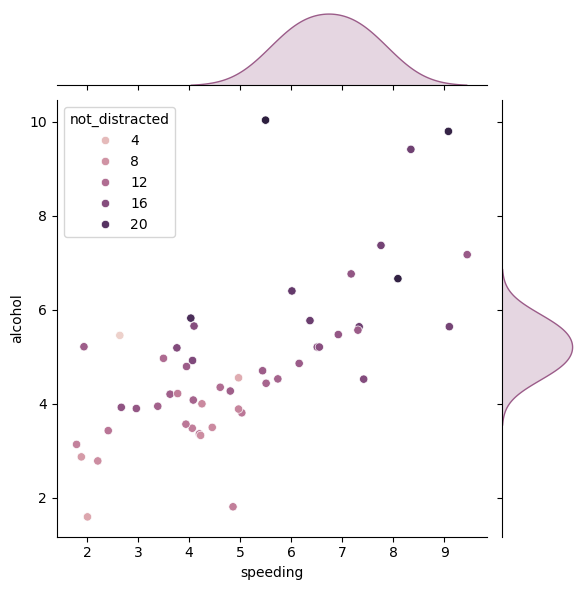

In [7]:
sns.jointplot(x='speeding',y='alcohol',data=crash,kind='scatter')
sns.jointplot(x='speeding',y='alcohol',data=crash,kind='scatter',hue='not_distracted')
plt.show()

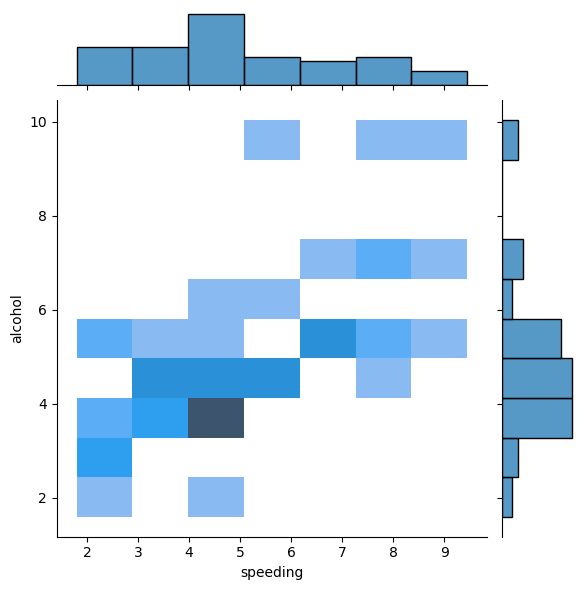

In [8]:
sns.jointplot(x='speeding', y='alcohol', data=crash, kind='hist')
plt.show()

## KDE Plot

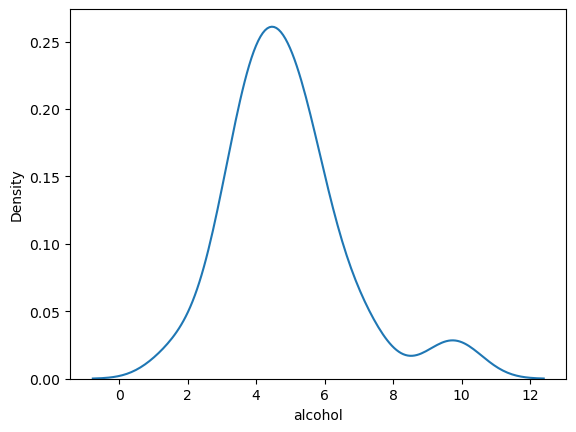

In [9]:
sns.kdeplot(crash['alcohol'])
plt.show()

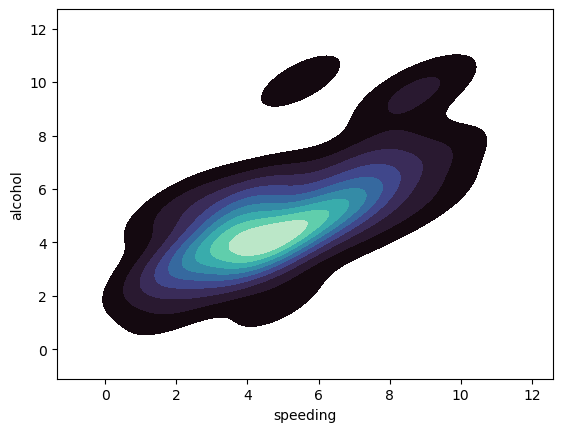

In [10]:
sns.kdeplot(x=crash['speeding'], y=crash['alcohol'], fill=True, cmap='mako')
plt.show()

## Pair Plot

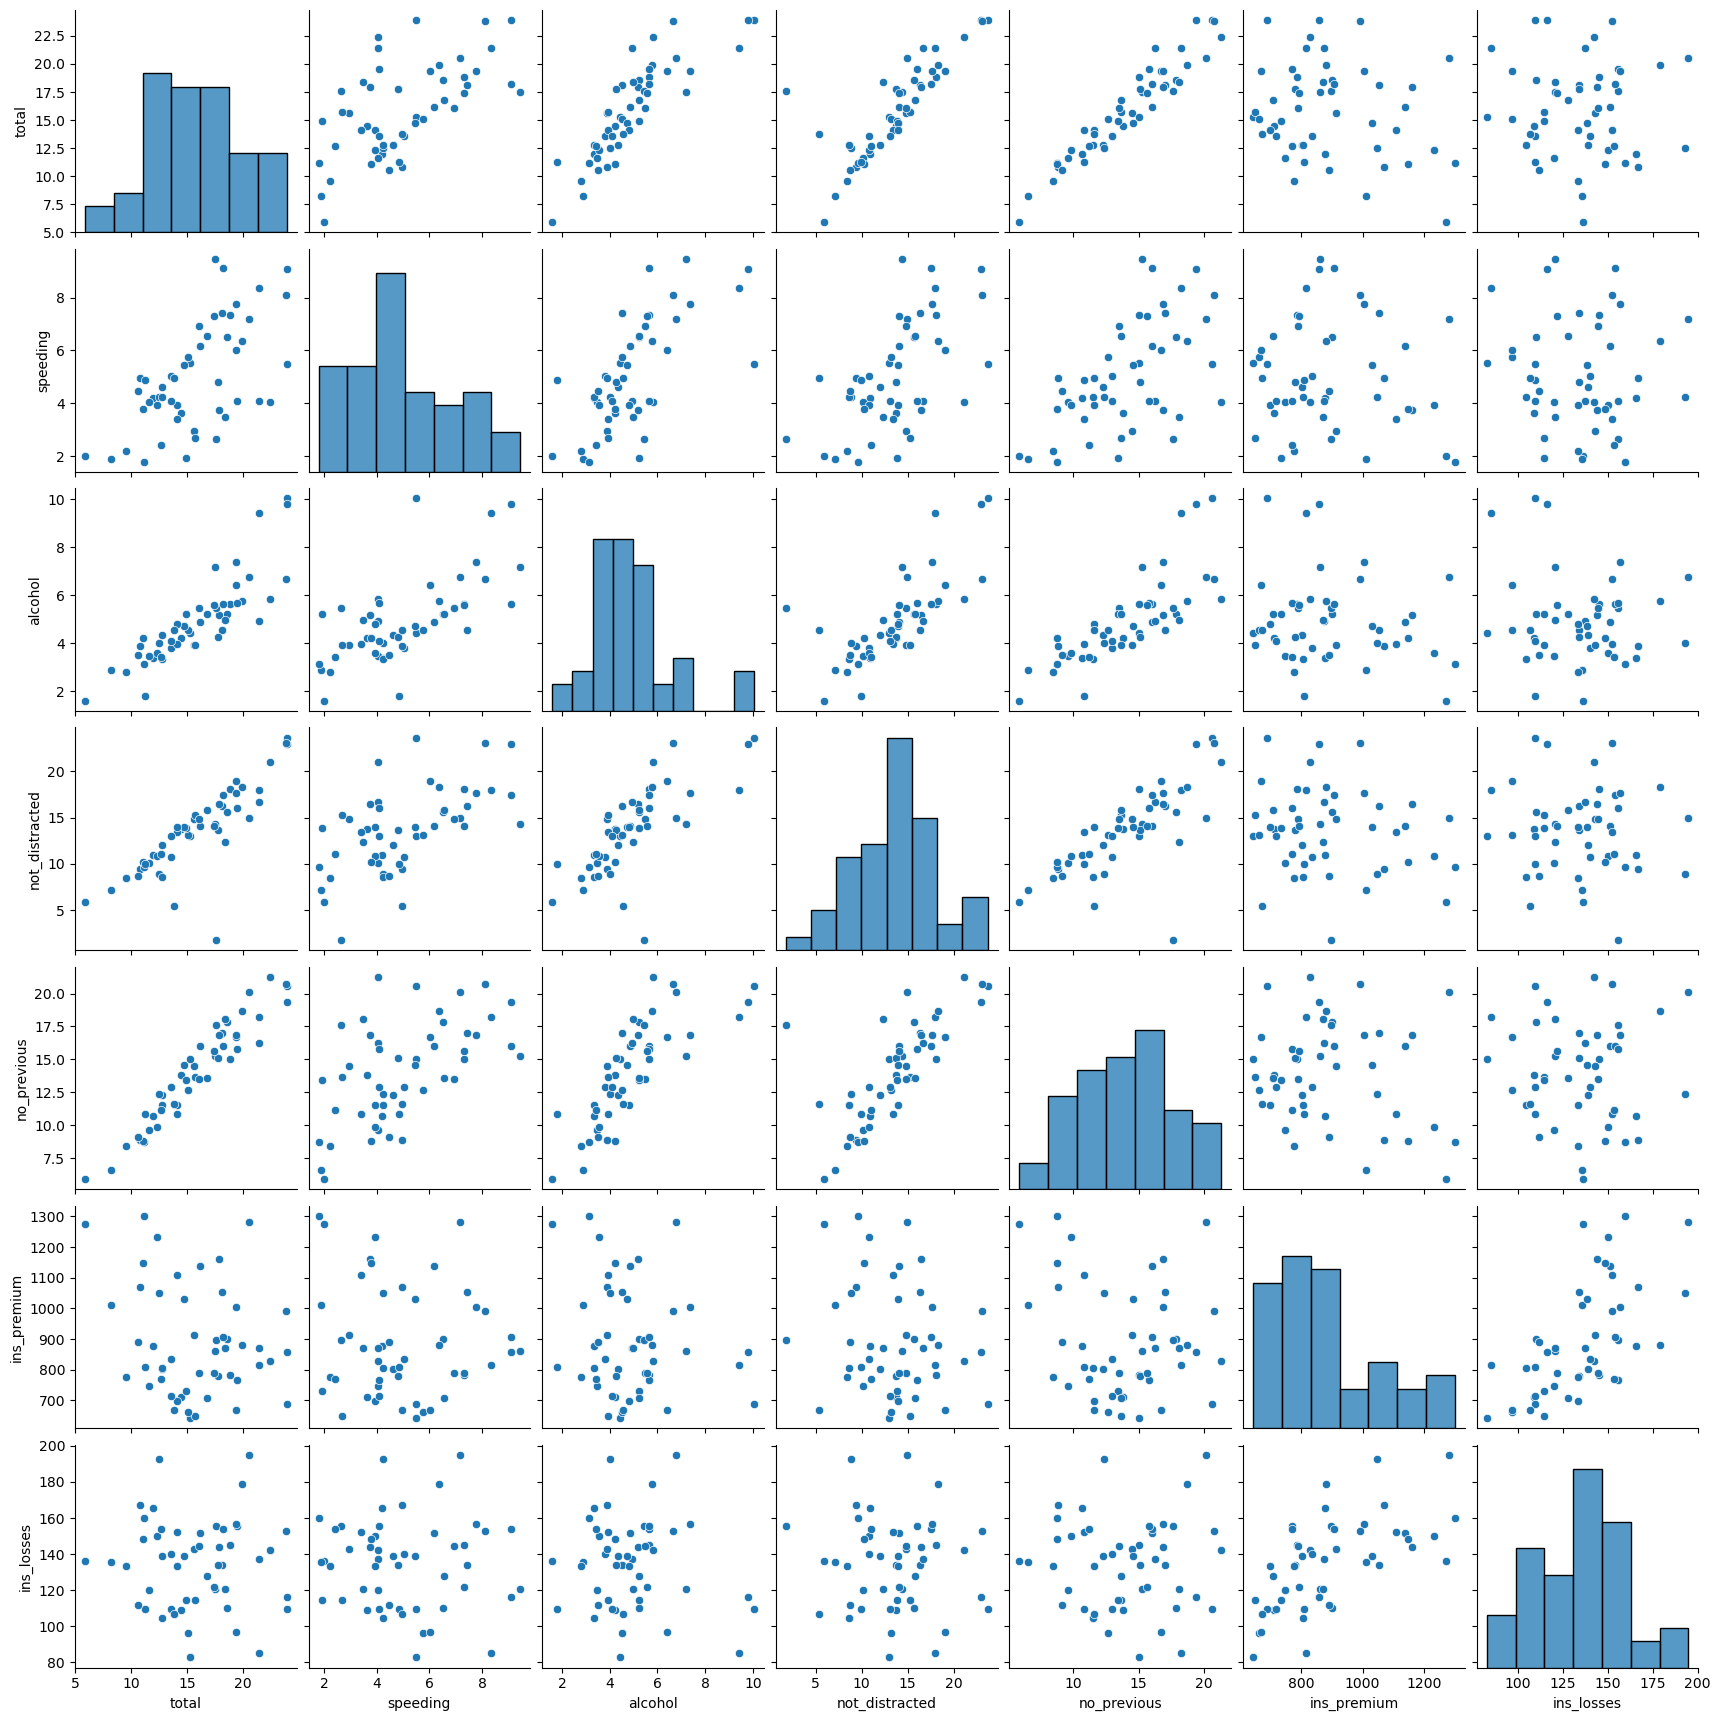

In [11]:
sns.pairplot(crash)
plt.show()

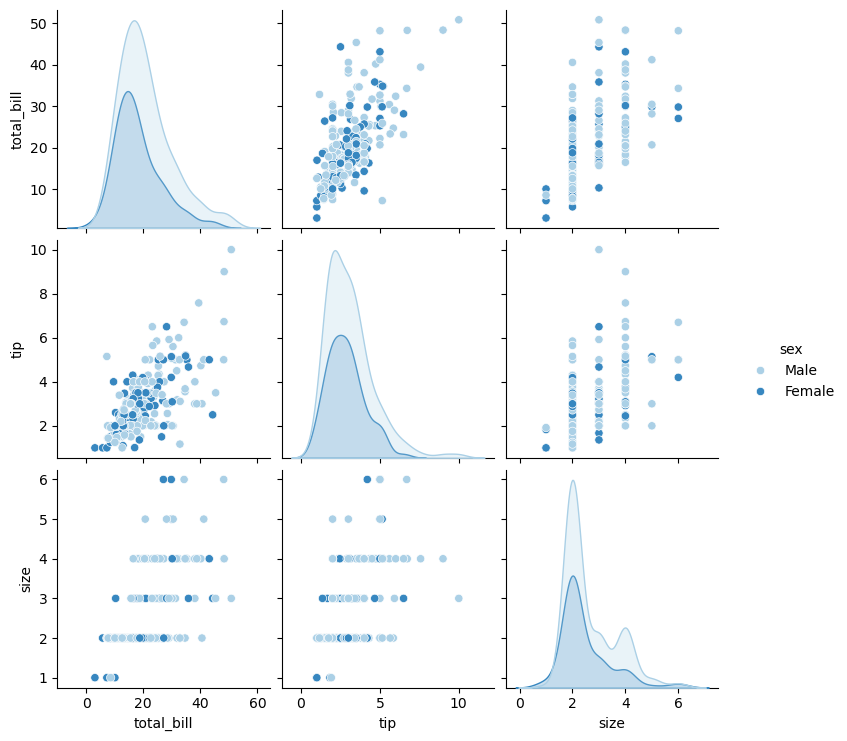

In [12]:
tips=sns.load_dataset('tips')
sns.pairplot(data=tips,hue='sex',palette='Blues')
plt.show()

## Rug Plot

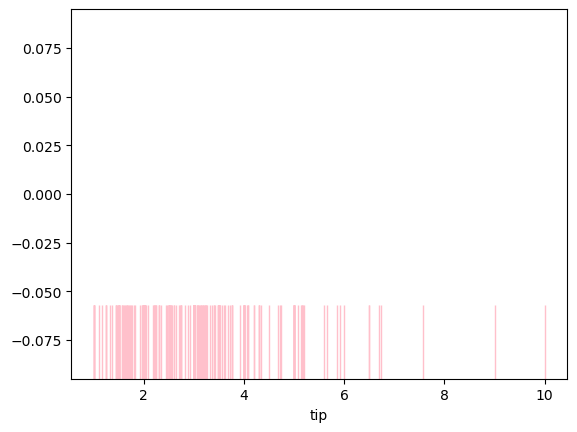

In [13]:
sns.rugplot(tips['tip'],color='pink',height=0.2)
plt.show()

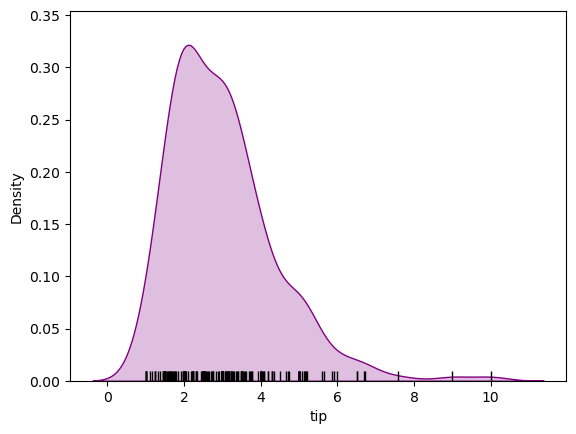

In [14]:
sns.kdeplot(tips['tip'], fill=True, color='purple')
sns.rugplot(tips['tip'], color='black')
plt.show()


# STYLING

<Figure size 800x500 with 0 Axes>

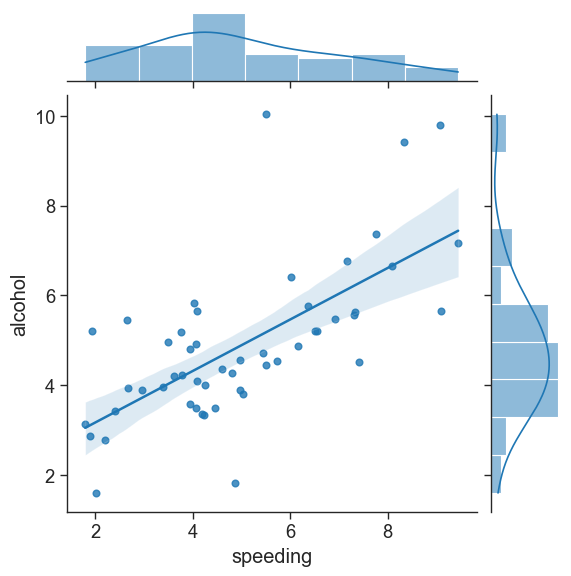

In [15]:
datsns.set_style('ticks')
plt.figure(figsize=(8,5))
sns.set_context('paper',font_scale=1.5) # EXCEPT PAPER YOU CAN ALSO USE ['TALK'] & ['POSTER'] talk is usally used for presentations
sns.jointplot(x='speeding',y='alcohol',data=crash,kind='reg')

# sns.despine(left=True,bottom=True)  ## remove the spine of x and y axis
plt.show()

# CATEGORICAL PLOTS

## Bar Plot

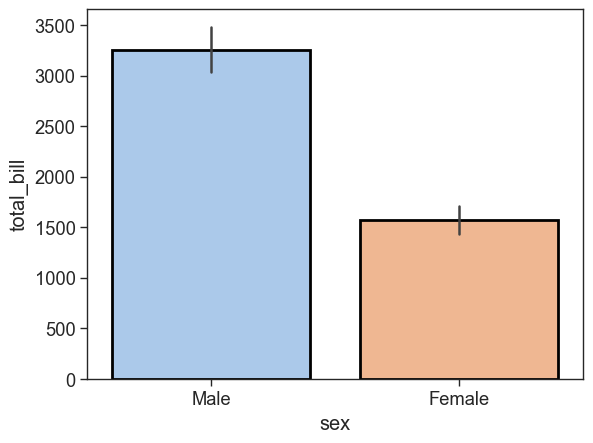

In [16]:
sns.barplot(y='total_bill',x='sex',hue='sex',legend=False,data=tips,estimator=sum,palette='pastel',edgecolor='black',linewidth=2)
# for estimator you can also use np.mean,var,std,median ## ALSO CAN USE LEN & SUM
plt.show()

## Count Plot

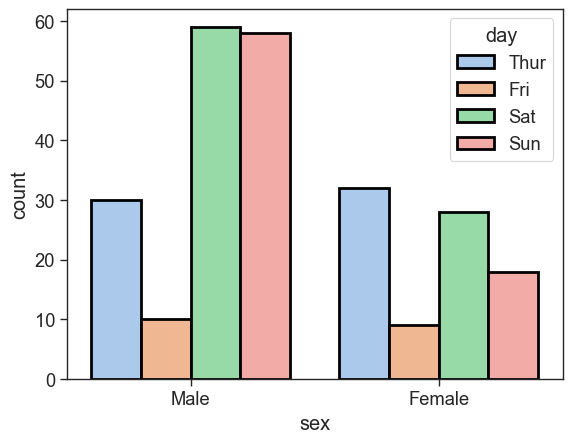

In [17]:
sns.countplot(x='sex',data=tips,hue='day',palette='pastel',edgecolor='black',linewidth=2)
plt.show()

## Box Plot

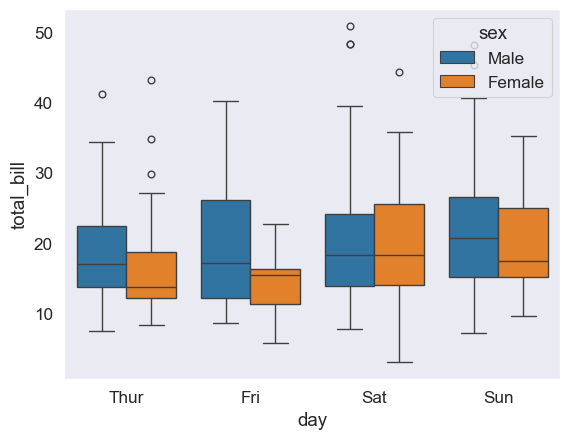

In [132]:
sns.boxplot(x='day',y='total_bill',hue='sex',data=tips)
plt.show()

## Violin Plot

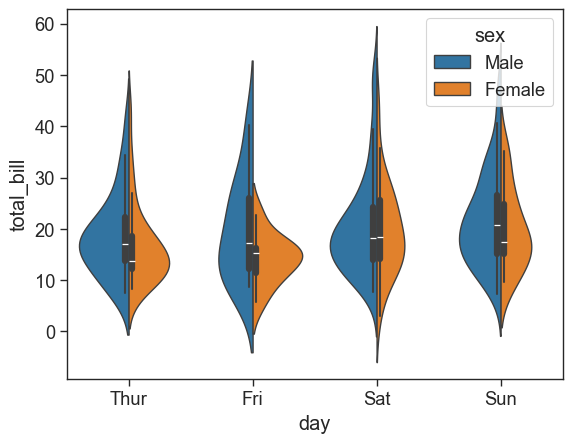

In [19]:
sns.violinplot(x='day',y='total_bill',hue='sex',data=tips,split=True)

plt.show()

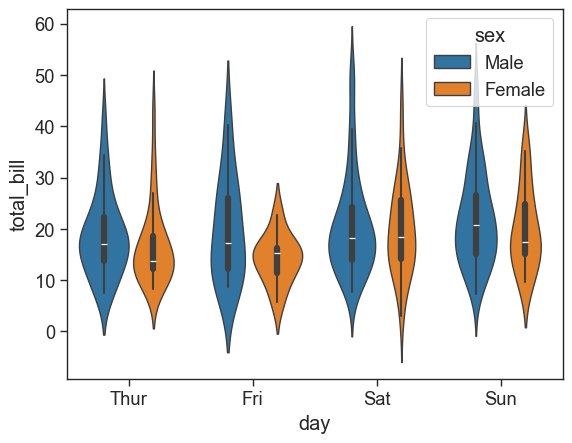

In [20]:
sns.violinplot(x='day',y='total_bill',hue='sex',data=tips)
plt.show()

## Strip Plot

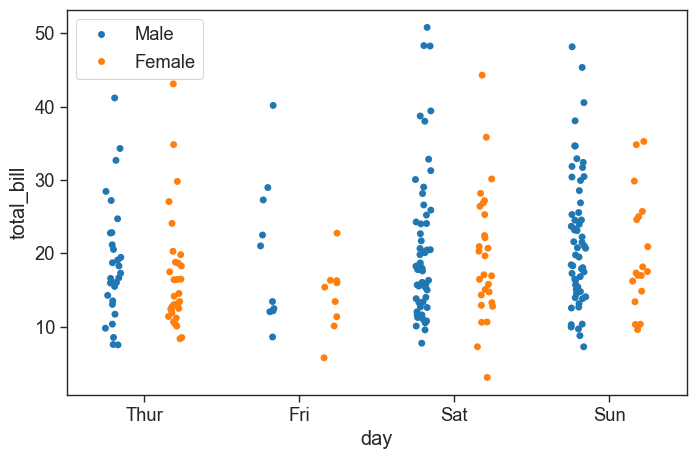

In [21]:
plt.figure(figsize=(8,5))
sns.stripplot(x='day',y='total_bill',data=tips,jitter=True,hue='sex',dodge=True)
# jitter spreads the values a bit # DODGE speartes the men and women values
plt.legend(loc=0)
plt.show()

## Swarm Plot

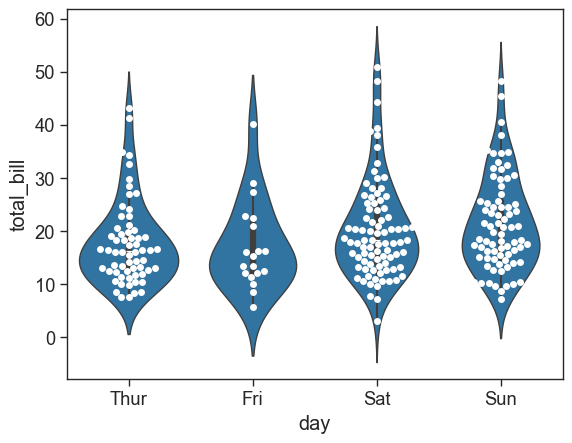

In [22]:
sns.violinplot(x='day',y='total_bill',data=tips)
sns.swarmplot(x='day',y='total_bill',data=tips,color='white')
plt.show()

# Palettes

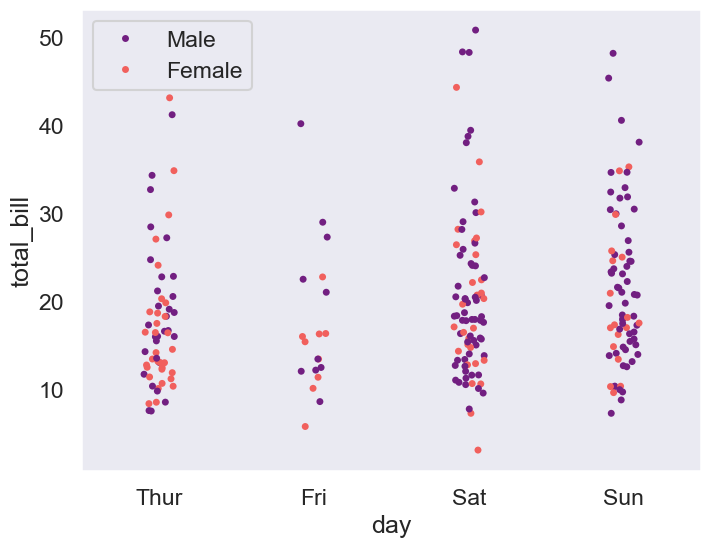

In [23]:
plt.figure(figsize=(8,6))
sns.set_style('dark')
sns.set_context('talk')
# You can use Matplotlibs color maps for color styling
# https://matplotlib.org/3.3.1/tutorials/colors/colormaps.html
sns.stripplot(x='day',y='total_bill',data=tips,hue='sex',palette='magma')

# Add the optional legend with a location number (best: 0, 
# upper right: 1, upper left: 2, lower left: 3, lower right: 4,
# https://matplotlib.org/3.3.1/api/_as_gen/matplotlib.pyplot.legend.html)
# or supply a tuple of x & y from lower left
plt.legend(loc=0)

plt.show()

# Matrix Plots

## Heatmaps

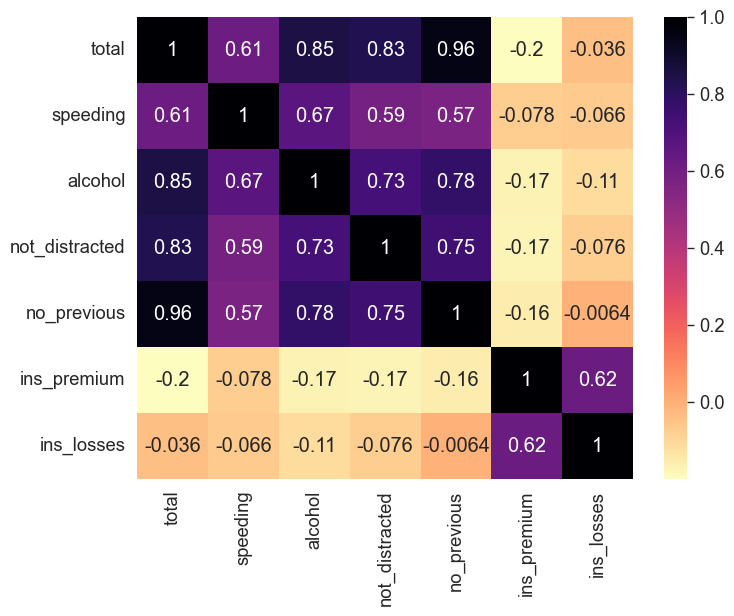

In [42]:
plt.figure(figsize=(8,6))
sns.set_context('paper',font_scale=1.5)

mx=crash.corr(numeric_only=True)
sns.heatmap(mx,annot=True,cmap='magma_r')## magma for normal and IF U WISH TO REVERSE THE COLOR SCHEME USE MAGMA_R

plt.show()

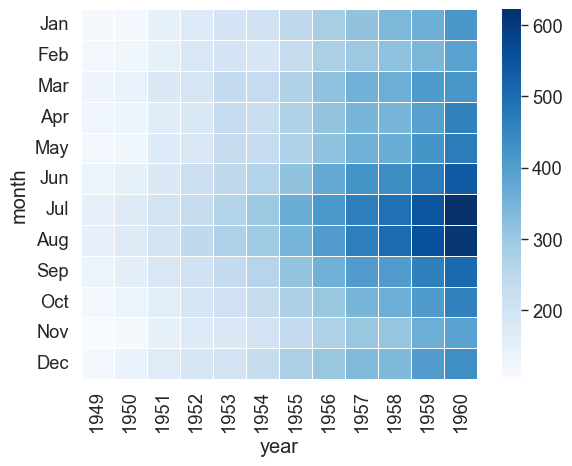

In [58]:
flight=sns.load_dataset('flights')
flights=flight.pivot_table(index='month',columns='year',values='passengers',observed=False)
flights
sns.heatmap(flights,cmap='Blues',edgecolor='white',linewidth=0.5)
plt.show()


## Cluster Maps

In [70]:
# iris=sns.load_dataset('iris')
# species=iris.pop('species')
# sns.clustermap(iris)
# plt.show()

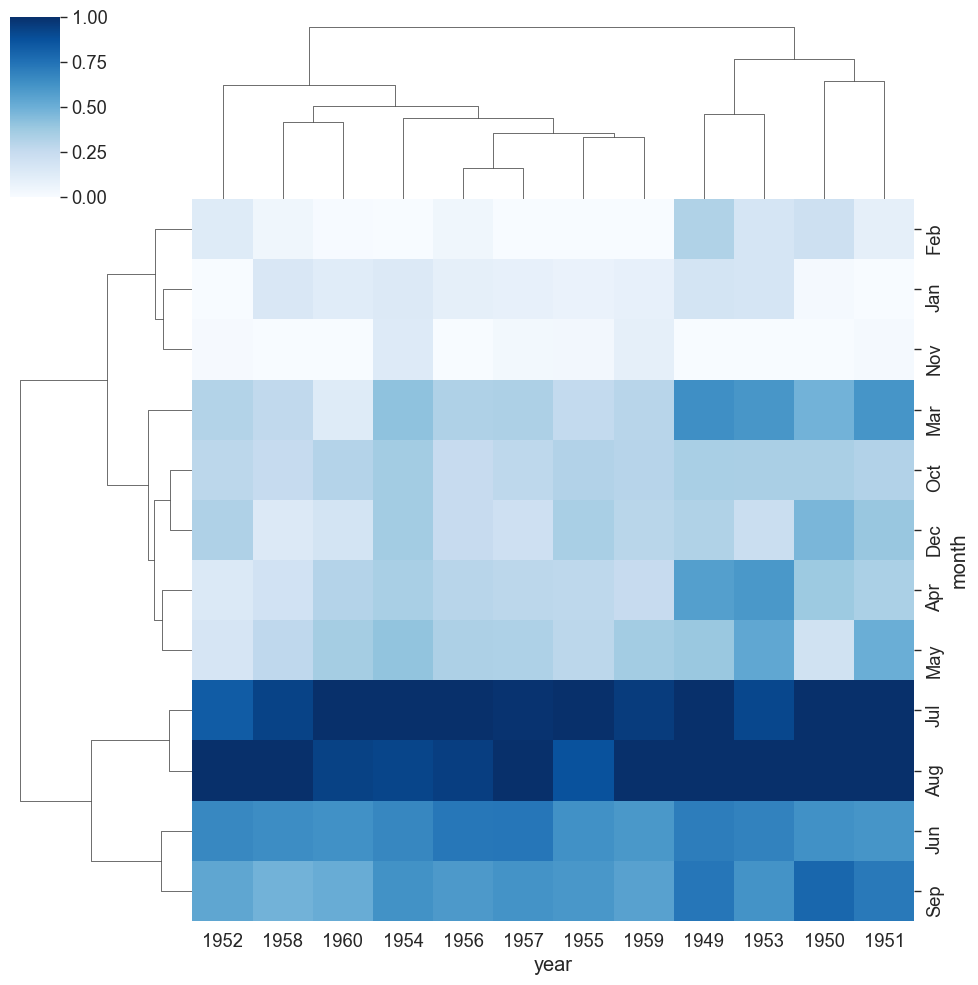

In [68]:

sns.clustermap(flights,cmap='Blues',standard_scale=1)
plt.show()

## PairGrid


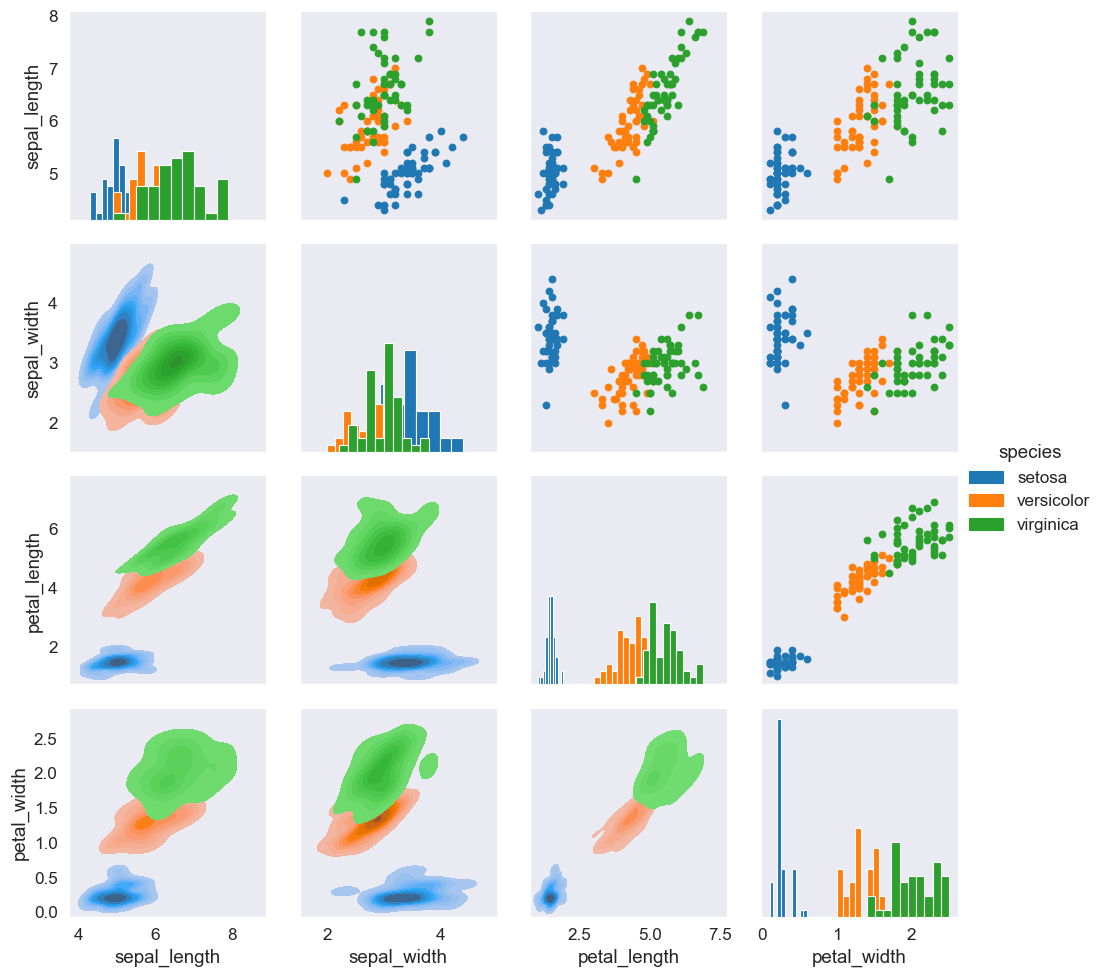

In [134]:
iris=sns.load_dataset('iris')
iris_g=sns.PairGrid(iris,hue='species')

iris_g.map_diag(plt.hist)
#iris_g.map_offdiag(plt.scatter)
iris_g.map_upper(plt.scatter)
iris_g.map_lower(sns.kdeplot,fill=True)
iris_g.add_legend()

plt.show()

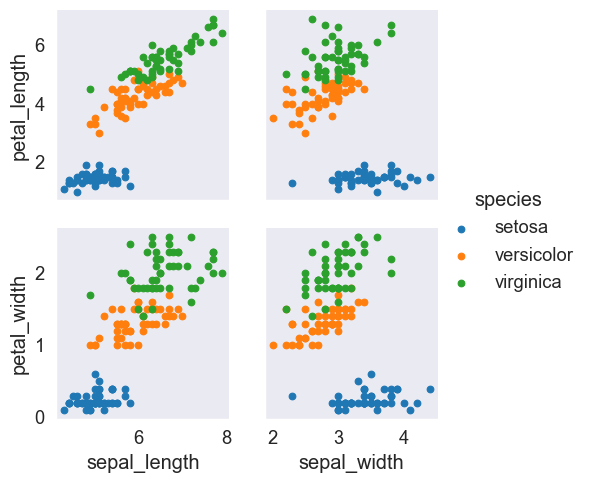

In [87]:
iris_g=sns.PairGrid(iris,hue='species',x_vars=['sepal_length','sepal_width'],y_vars=['petal_length','petal_width'])
iris_g.map(plt.scatter)
iris_g.add_legend()
plt.show()

## Facet Grid

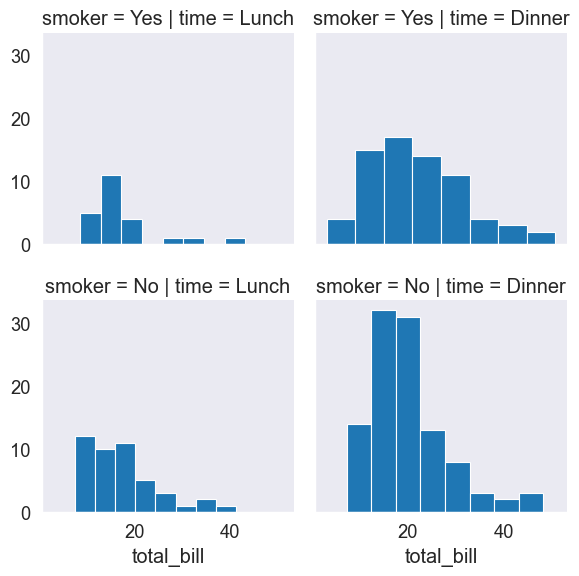

In [94]:
tips_fg=sns.FacetGrid(tips,col='time',row='smoker')
tips_fg.map(plt.hist,'total_bill',bins=8)

plt.show()

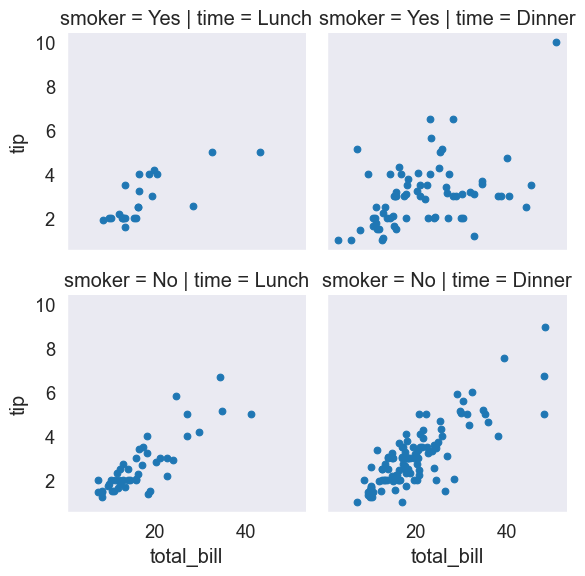

In [95]:
tips_fg=sns.FacetGrid(tips,col='time',row='smoker')

tips_fg.map(plt.scatter,'total_bill','tip')
plt.show()

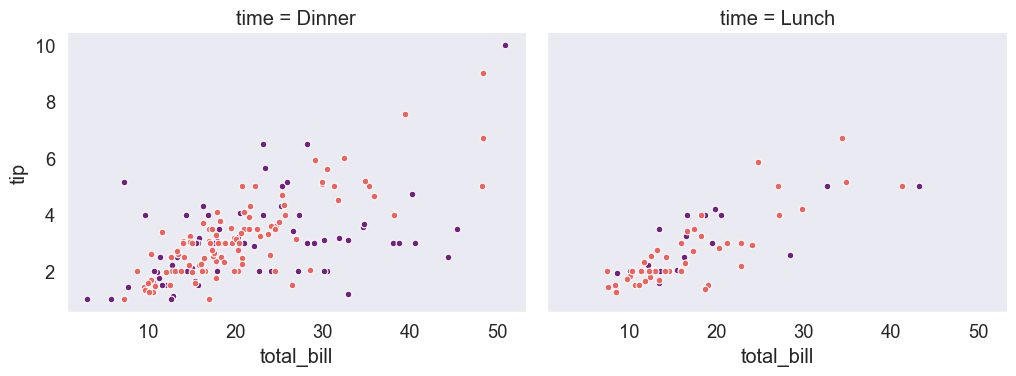

In [103]:
tips_fg=sns.FacetGrid(tips,col='time',hue='smoker',height=4,aspect=1.3,col_order=['Dinner','Lunch'],palette='magma')
tips_fg.map(plt.scatter,'total_bill','tip',edgecolor='white')
plt.show()

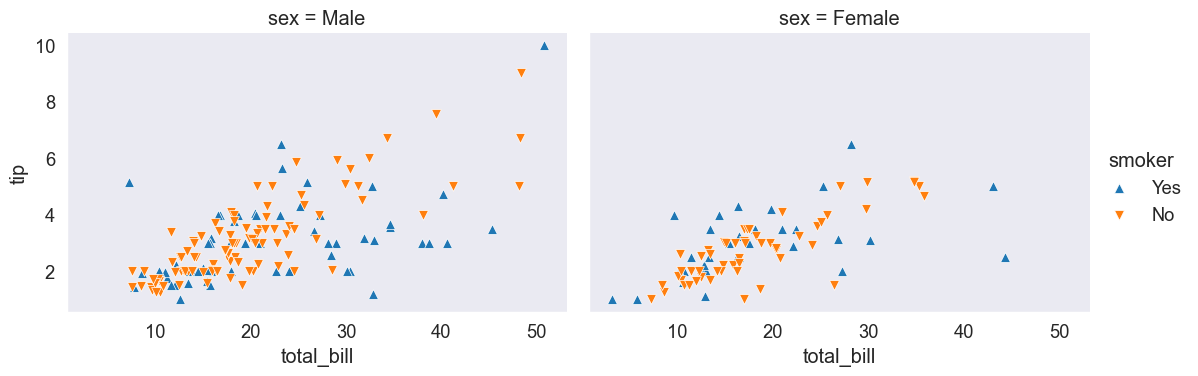

In [109]:
kws=dict(s=50,linewidth=.5,edgecolor='white')
tips_fg=sns.FacetGrid(tips,col='sex',hue='smoker',height=4,aspect=1.4,hue_order=['Yes','No'],hue_kws=dict(marker=['^',"v"]))
tips_fg.map(plt.scatter,'total_bill','tip',**kws)
tips_fg.add_legend()
plt.show()

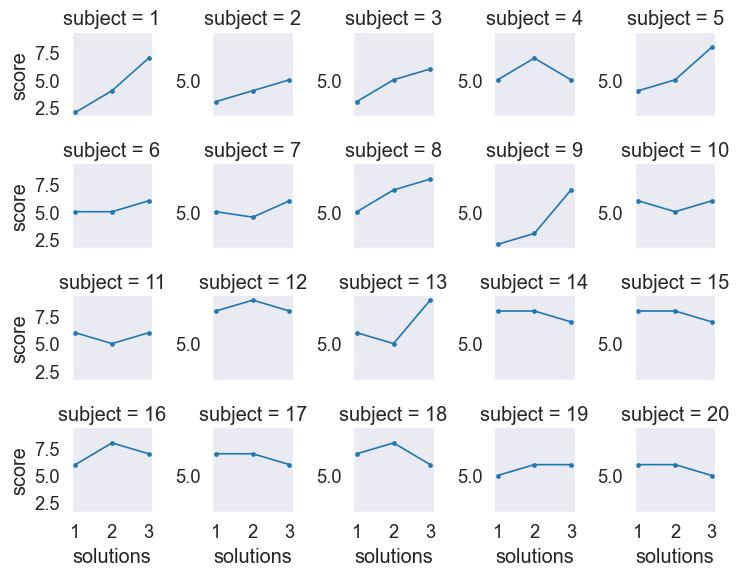

In [116]:
att=sns.load_dataset('attention')
att_fg=sns.FacetGrid(att,col='subject',col_wrap=5,height=1.5)
att_fg.map(plt.plot,'solutions','score',marker='.')
plt.show()

## Regression Plot

<Figure size 800x600 with 0 Axes>

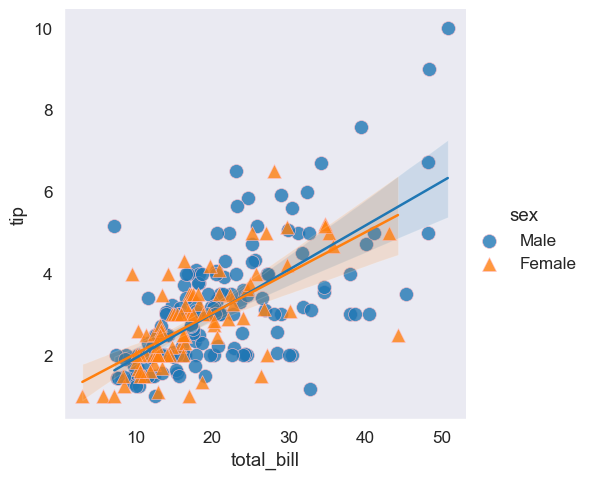

In [125]:
plt.figure(figsize=(8,6))
sns.set_context('paper',font_scale=1.4)
sns.lmplot(x='total_bill',y='tip',hue='sex',data=tips,markers=['o','^'],scatter_kws={'s':100,'linewidths':0.5,'edgecolor':'pink'})
plt.show()

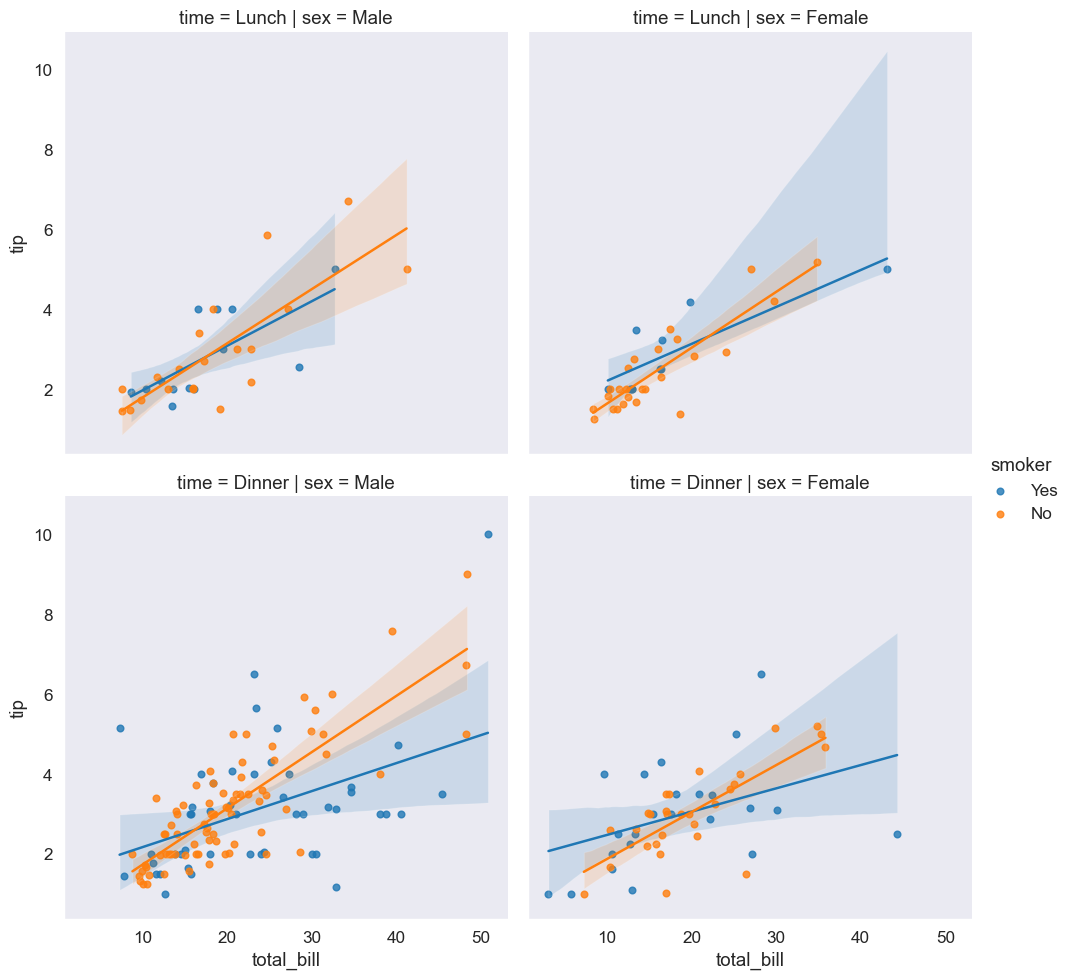

In [130]:
sns.lmplot(x='total_bill',y='tip',col='sex',row='time',data=tips,hue='smoker')
plt.show()